In [37]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import curve_fit

In [38]:
dataF = np.load('dataF.npy')
dataN = np.load('dataN.npy')
dataO = np.load('dataO.npy')
dataS = np.load('dataS.npy')
dataZ = np.load('dataZ.npy')

data = dataF[0]
files = [dataF, dataN, dataO, dataS, dataZ]
filenames = ['dataF', 'dataN', 'dataO', 'dataS', 'dataZ']

filenames_tseriesF = ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10',
                     'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20',
                     'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29', 'F30',
                     'F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40',
                     'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47', 'F48', 'F49', 'F50',
                     'F51', 'F52', 'F53', 'F54', 'F55', 'F56', 'F57', 'F58', 'F59', 'F60',
                     'F61', 'F62', 'F63', 'F64', 'F65', 'F66', 'F67', 'F68', 'F69', 'F70',
                     'F71', 'F72', 'F73', 'F74', 'F75', 'F76', 'F77', 'F78', 'F79', 'F80',
                     'F81', 'F82', 'F83', 'F84', 'F85', 'F86', 'F87', 'F88', 'F89', 'F90',
                     'F91', 'F92', 'F93', 'F94', 'F95', 'F96', 'F97', 'F98', 'F99', 'F100']

filenames_tseriesN = ['N01', 'N02', 'N03', 'N04', 'N05', 'N06', 'N07', 'N08', 'N09', 'N10',
                     'N11', 'N12', 'N13', 'N14', 'N15', 'N16', 'N17', 'N18', 'N19', 'N20',
                     'N21', 'N22', 'N23', 'N24', 'N25', 'N26', 'N27', 'N28', 'N29', 'N30',
                     'N31', 'N32', 'N33', 'N34', 'N35', 'N36', 'N37', 'N38', 'N39', 'N40',
                     'N41', 'N42', 'N43', 'N44', 'N45', 'N46', 'N47', 'N48', 'N49', 'N50',
                     'N51', 'N52', 'N53', 'N54', 'N55', 'N56', 'N57', 'N58', 'N59', 'N60',
                     'N61', 'N62', 'N63', 'N64', 'N65', 'N66', 'N67', 'N68', 'N69', 'N70',
                     'N71', 'N72', 'N73', 'N74', 'N75', 'N76', 'N77', 'N78', 'N79', 'N80',
                     'N81', 'N82', 'N83', 'N84', 'N85', 'N86', 'N87', 'N88', 'N89', 'N90',
                     'N91', 'N92', 'N93', 'N94', 'N95', 'N96', 'N97', 'N98', 'N99', 'N100']

filenames_tseriesO = ['O01', 'O02', 'O03', 'O04', 'O05', 'O06', 'O07', 'O08', 'O09', 'O10',
                     'O11', 'O12', 'O13', 'O14', 'O15', 'O16', 'O17', 'O18', 'O19', 'O20',
                     'O21', 'O22', 'O23', 'O24', 'O25', 'O26', 'O27', 'O28', 'O29']

time = np.linspace(0, 23.6, len(dataF[0]))

In [39]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

def prox(data):
    data_dict = Counter(data) 
    x = sorted(data_dict.keys())
    x = np.array(x)
    y = [data_dict[i] for i in x]
    y = np.array(y)

    # Fit Gaussian curve to scatter data
    popt, pcov = curve_fit(gaussian, x, y, p0=[max(y), np.mean(x), np.std(x)])

    # Generate smooth fitted curve
    x_fit = np.linspace(min(x), max(x), max(x)-min(x)+1)
    x_fit = np.array(x_fit)
    y_fit = gaussian(x_fit, *popt)
    y_fit = np.array(y_fit)

    return x, y, x_fit, y_fit, popt

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
C:\Users\rjnar\AppData\Local\Temp\ipykernel_32920\2116840942.py:12: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_title(f'dy = 1 $\mu$V, Gaussian Fit: Amplitude={popt[0]:.2f}, Mean={popt[1]:.2f}, Sigma={popt[2]:.2f}')
C:\Users\rjnar\AppData\Local\Temp\ipykernel_32920\2116840942.py:18: SyntaxWarning: invalid escape sequence '\m'
  axs[2].set_title(f'dy = 1 $\mu$V, Gaussian Fit: Amplitude={popt[0]:.2f}, Mean={popt[1]:.2f}, Sigma={popt[2]:.2f}')


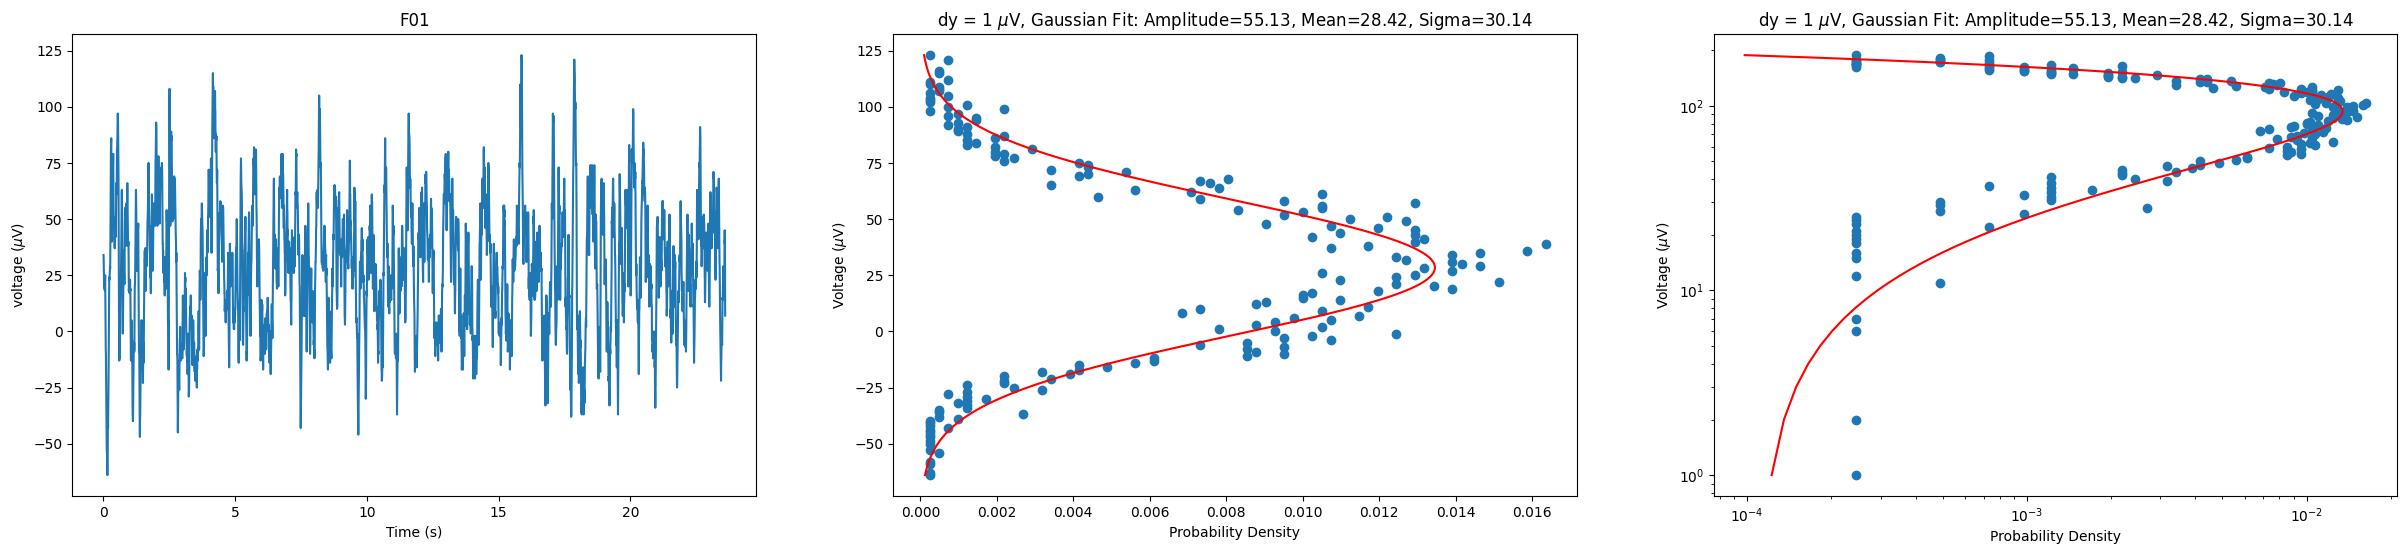

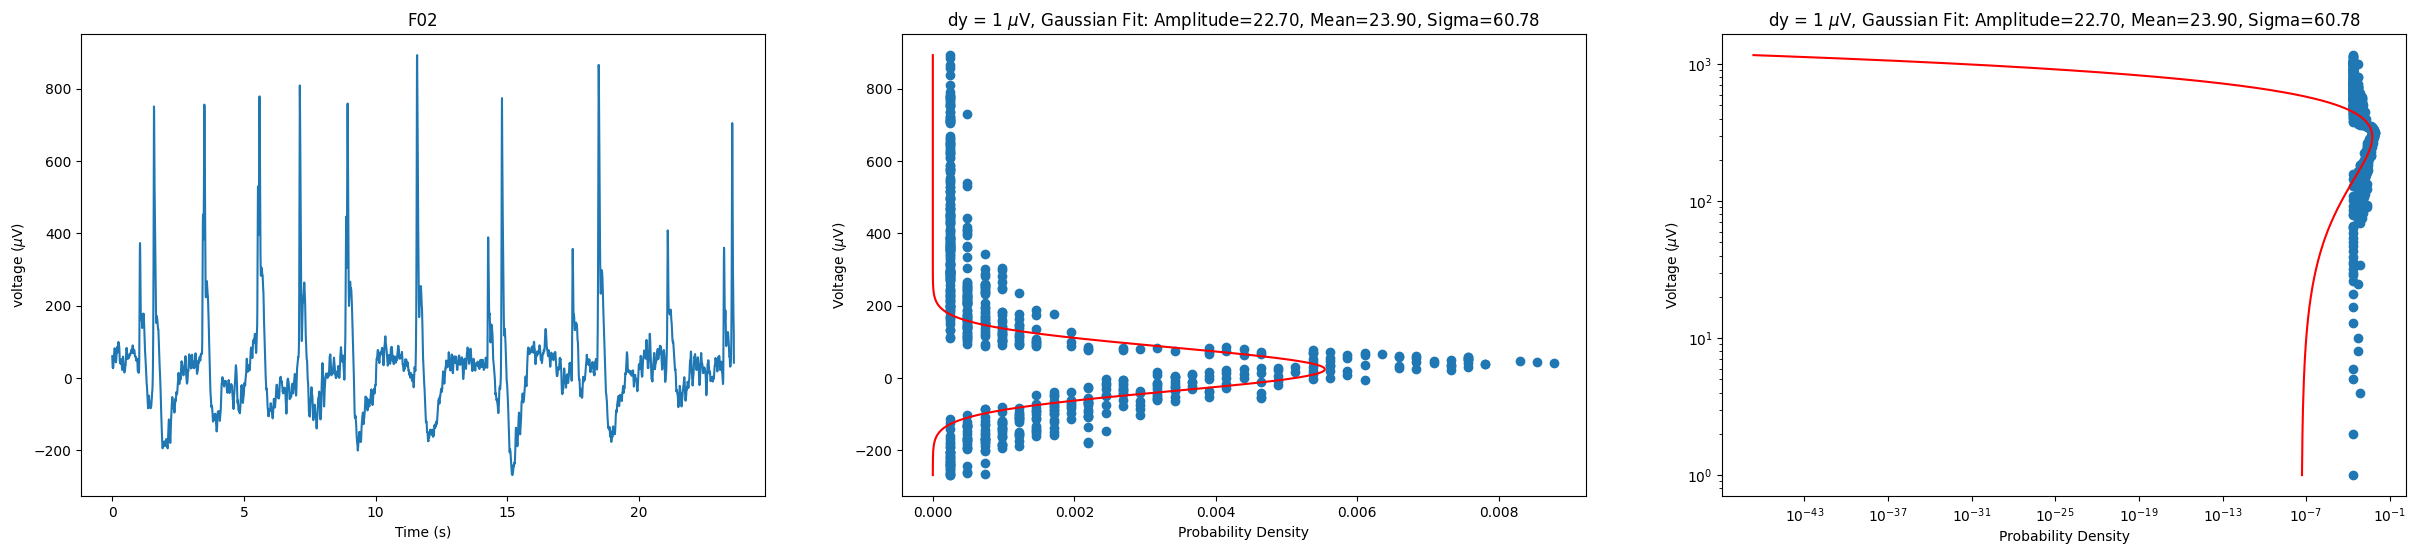

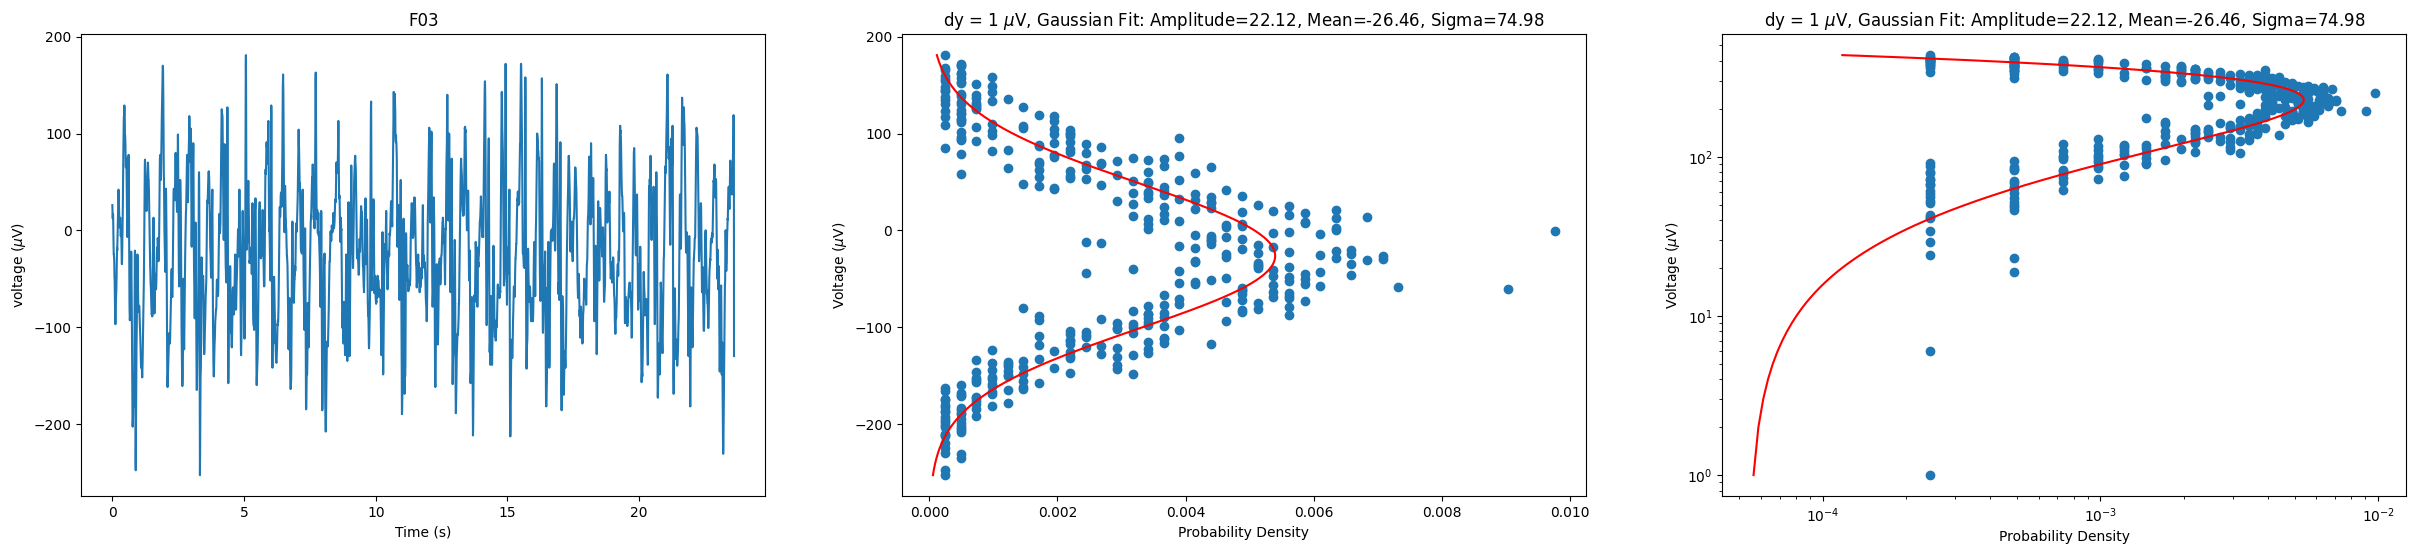

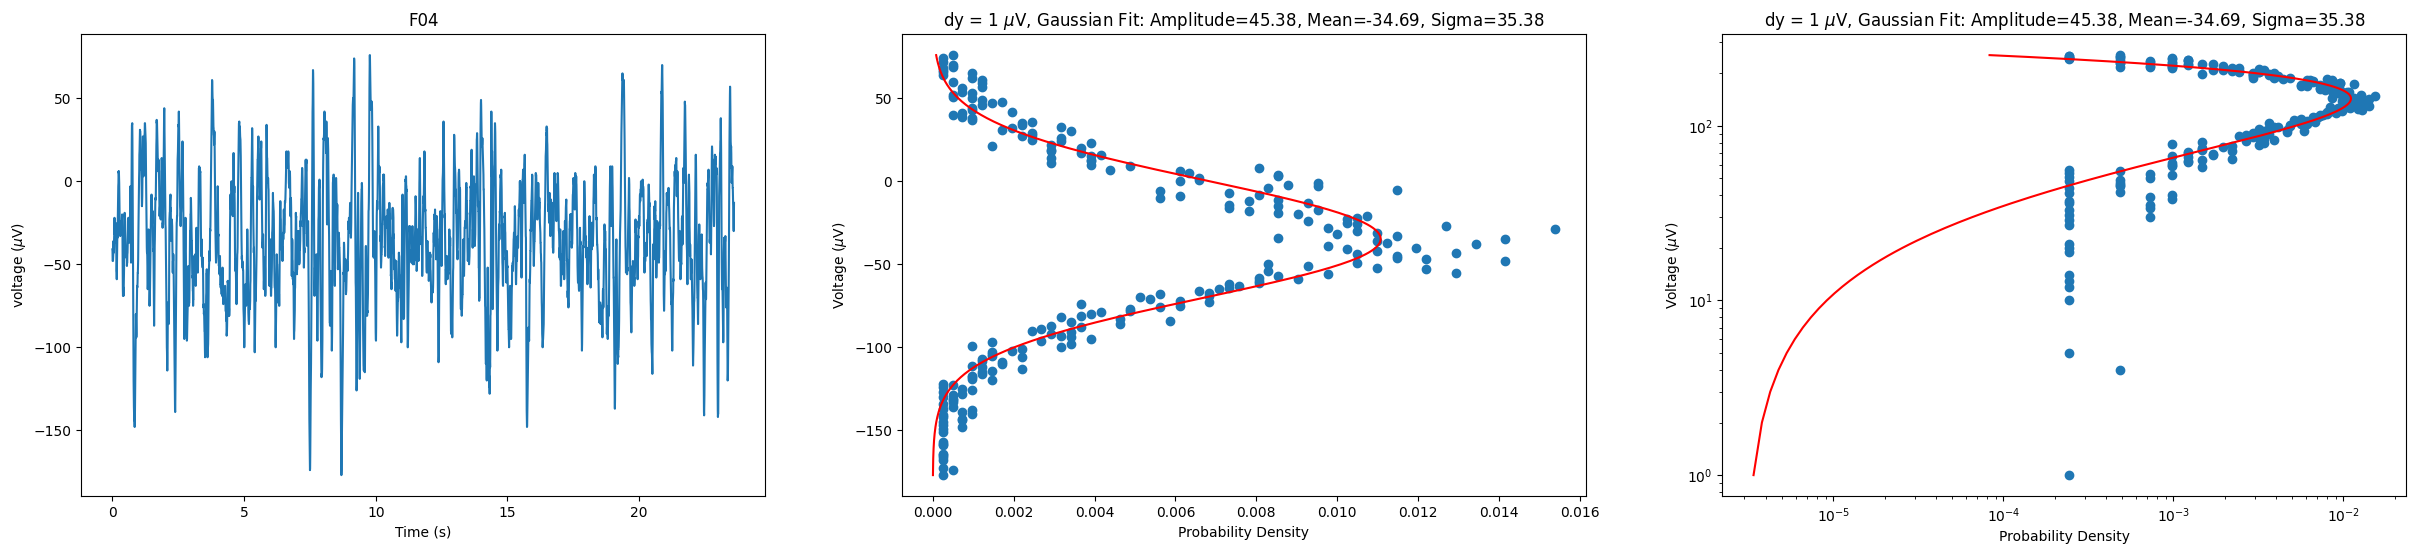

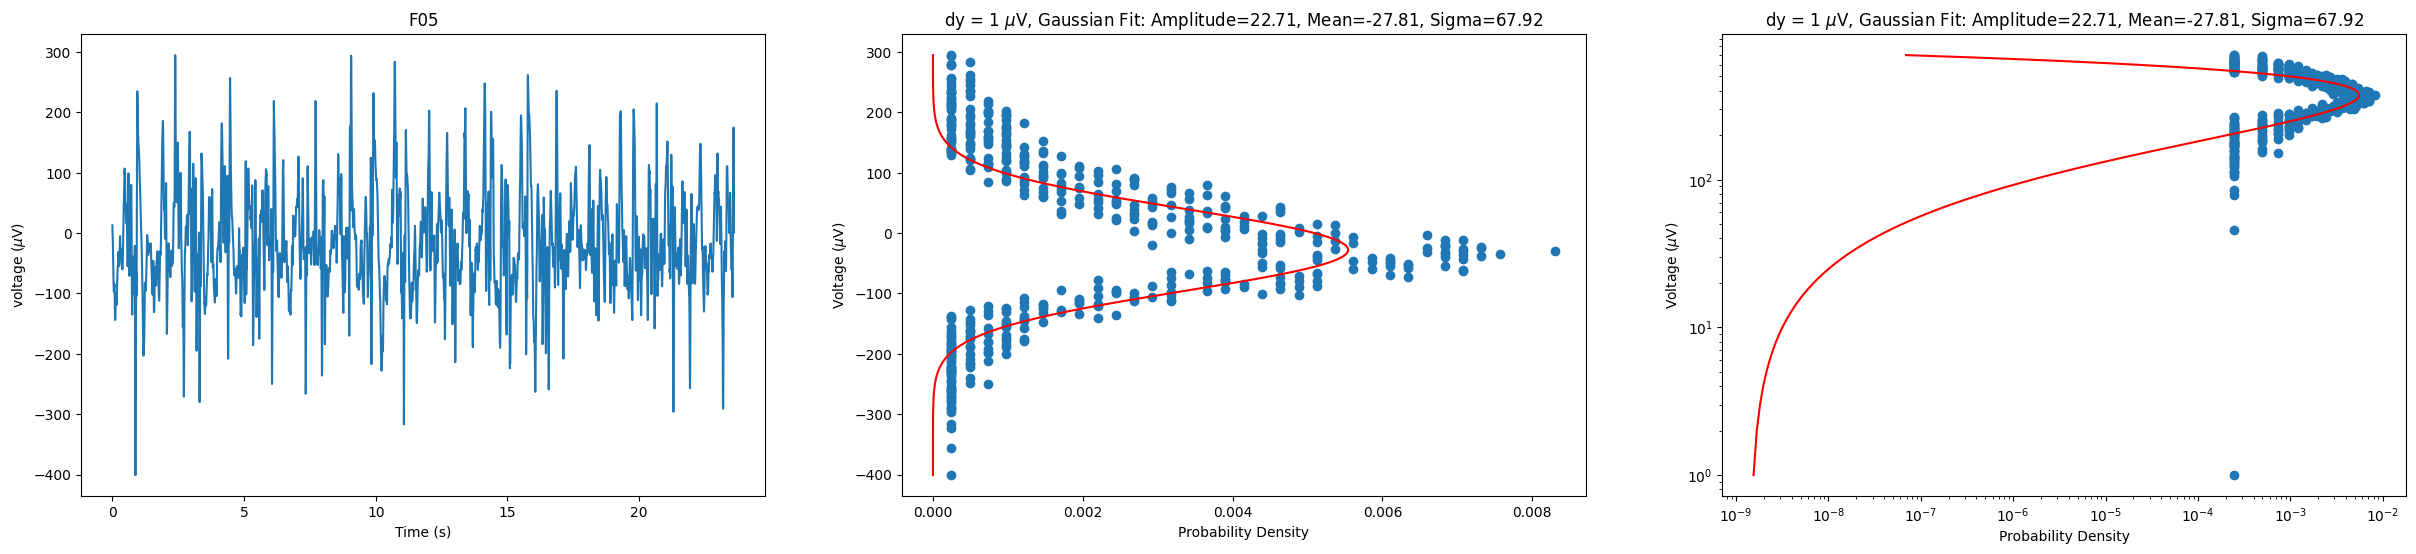

In [40]:
for i in range(5):
    fig, axs = plt.subplots(1, 3, figsize=(30, 6))

    x, y, x_fit, y_fit, popt = prox(dataF[i])
    axs[0].plot(time, dataF[i])
    axs[0].set_title(filenames_tseriesF[i])
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel(r'voltage ($\mu$V)')

    axs[1].scatter(y/4097, x)
    axs[1].plot(y_fit/4097, x_fit, color='red')
    axs[1].set_title(f'dy = 1 $\mu$V, Gaussian Fit: Amplitude={popt[0]:.2f}, Mean={popt[1]:.2f}, Sigma={popt[2]:.2f}')
    axs[1].set_xlabel('Probability Density')
    axs[1].set_ylabel(r'Voltage ($\mu$V)')

    axs[2].scatter(y/4097, x+(-1*min(x))+1)
    axs[2].plot(y_fit/4097, x_fit+(-1*min(x_fit))+1, color='red')
    axs[2].set_title(f'dy = 1 $\mu$V, Gaussian Fit: Amplitude={popt[0]:.2f}, Mean={popt[1]:.2f}, Sigma={popt[2]:.2f}')
    axs[2].set_xlabel('Probability Density')
    axs[2].set_ylabel(r'Voltage ($\mu$V)')
    axs[2].set_xscale('log')
    axs[2].set_yscale('log')

    plt.savefig(f'{filenames_tseriesF[i]}.png')
    